In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [77]:
#read the csv file
df = pd.read_csv("sales.csv")

In [78]:
#show the information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   order_id  149116 non-null  int64  
 1   date      149116 non-null  object 
 2   store     149116 non-null  object 
 3   product   149116 non-null  object 
 4   quantity  149116 non-null  int64  
 5   sales     149116 non-null  float64
dtypes: float64(1), int64(2), object(3)
memory usage: 6.8+ MB


In [79]:
#search how much missing values in each column
df.isnull().sum()

order_id    0
date        0
store       0
product     0
quantity    0
sales       0
dtype: int64

In [80]:
#search how much duplicated values in the dataset
df.duplicated().sum()

0

In [81]:
#ensure the date column is in datetime format
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y')

In [82]:
#extracting month, day, and day name from the date column
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_name'] = df['date'].dt.day_name()
df['price_per_unit'] = df['sales'] / df['quantity']

In [83]:
#show the information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        149116 non-null  int64         
 1   date            149116 non-null  datetime64[ns]
 2   store           149116 non-null  object        
 3   product         149116 non-null  object        
 4   quantity        149116 non-null  int64         
 5   sales           149116 non-null  float64       
 6   month           149116 non-null  int32         
 7   day             149116 non-null  int32         
 8   day_name        149116 non-null  object        
 9   price_per_unit  149116 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int32(2), int64(2), object(3)
memory usage: 10.2+ MB


In [84]:
#show the statistical summary of the dataset

df[['quantity','sales','price_per_unit']].describe()

,quantity,sales,price_per_unit
count,149116.000000,149116.000000,149116.000000
mean,1.438276,4.686367,3.382219
std,0.542509,4.227099,2.658723
min,1.000000,0.800000,0.800000
25%,1.000000,3.000000,2.500000
50%,1.000000,3.750000,3.000000
75%,2.000000,6.000000,3.750000
max,8.000000,360.000000,45.000000


In [85]:
#show the skewness of the dataset
df[['quantity','sales','price_per_unit']].skew()

quantity           0.799819
sales             41.745899
price_per_unit     8.455088
dtype: float64

In [86]:
#show the correlation between quantity, sales, and price per unit
df[['quantity','sales','price_per_unit']].corr()

,quantity,sales,price_per_unit
quantity,1.000000,0.356231,-0.123546
sales,0.356231,1.000000,0.685550
price_per_unit,-0.123546,0.685550,1.000000


QUESTION 1
Does every store have a different sales “personality”? (Apakah setiap toko punya “kepribadian” penjualan yang berbeda?)

In [87]:
# Calculating sales statistics, quantities, and average prices per store
store_summary = df.groupby('store').agg({
    'sales': ['sum','mean','std'],
    'quantity': ['sum','mean'],
    'price_per_unit': 'mean'
}).round(2)

store_summary

sales             quantity       price_per_unit
                       sum  mean   std      sum  mean           mean
store                                                               
Astoria          232243.91  4.59  2.88    70991  1.40           3.38
Hell's Kitchen   236511.17  4.66  5.84    71737  1.41           3.39
Lower Manhattan  230057.25  4.81  3.28    71742  1.50           3.37

In [88]:
# Analyzing product distribution across per stores
product_distribution = df.groupby(['store','product'])['sales'].sum().reset_index()
product_distribution.sort_values(['store','sales'], ascending=[True,False])

,store,product,sales
0,Astoria,Barista Espresso,27935.00
4,Astoria,Brewed Chai tea,27427.90
17,Astoria,Hot chocolate,26335.25
13,Astoria,Gourmet brewed coffee,23823.30
6,Astoria,Brewed herbal tea,16282.00
...,...,...,...
76,Lower Manhattan,House blend Beans,864.00
79,Lower Manhattan,Organic Chocolate,676.40
73,Lower Manhattan,Green tea,675.25
74,Lower Manhattan,Herbal tea,599.65


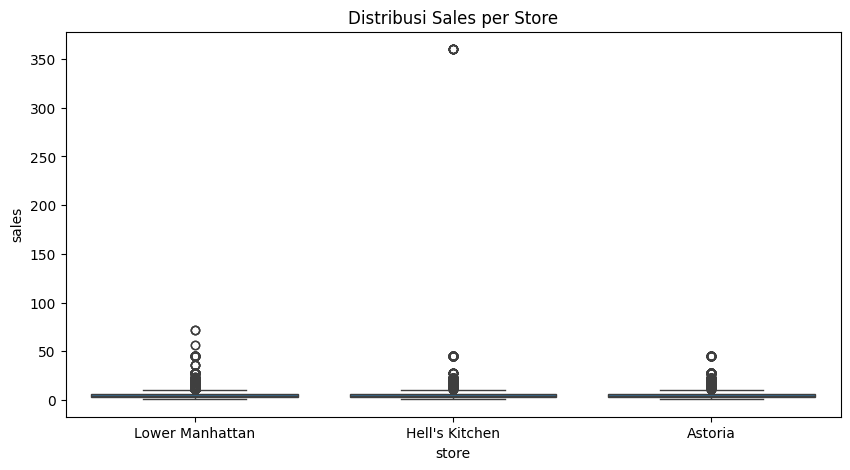

In [89]:
# Visualize the distribution of sales per store using boxplot
plt.figure(figsize=(10,5))
sns.boxplot(x='store', y='sales', data=df)
plt.title("Distribusi Sales per Store")
plt.show()

Conclusion:
Based on the boxplot distribution of sales, the median value for each store is relatively similar, indicating that there is no significant difference in the normal transaction patterns between stores. Hell's Kitchen has transactions with higher sales values than other stores. Therefore, there is no difference between stores in terms of average transaction levels. The difference lies in the level of volatility and extreme events at Hell's Kitchen.

Kesimpulan:
Berdasarkan boxplot distrubusi sales. Nilai tengah pada setiap store memiliki nilai yang relatif mirip, sehingga pola transaksi normal antar store tidak memiliki perbedaan yang signifikan. Hell's Kitchen memiliki transaksi dengan nilai sales yang lebih tinggi dibandingkan store lain. Sehingga kepribadian dia antara store tidak berbeda pada level rata-rata transaksi, perbedaan muncul pada tingkat volatilitas dan kejadian ekstrem di Hell's Kitchen.

QUESTION 2
Is there a pattern of “comfort drinking” during certain periods? (Apakah terdapat pola “comfort drink” pada periode tertentu?)

In [90]:
# Analyze the monthly sales trend for each product
monthly_product = df.groupby(['month','product'])['sales'].sum().reset_index()
monthly_product.head()

,month,product,sales
0,1,Barista Espresso,10461.20
1,1,Biscotti,2311.02
2,1,Black tea,375.90
3,1,Brewed Black tea,5535.50
4,1,Brewed Chai tea,8761.45


In [91]:
# Sort the monthly sales trend for each product by month and sales in descending order
monthly_product_sorted = monthly_product.sort_values(['month','sales'], ascending=[True,False])
monthly_product_sorted

,month,product,sales
0,1,Barista Espresso,10461.20
4,1,Brewed Chai tea,8761.45
17,1,Hot chocolate,8337.75
13,1,Gourmet brewed coffee,8072.10
3,1,Brewed Black tea,5535.50
...,...,...,...
154,6,Drinking Chocolate,612.16
173,6,Sugar free syrup,577.60
166,6,Organic Chocolate,380.00
160,6,Green tea,333.00


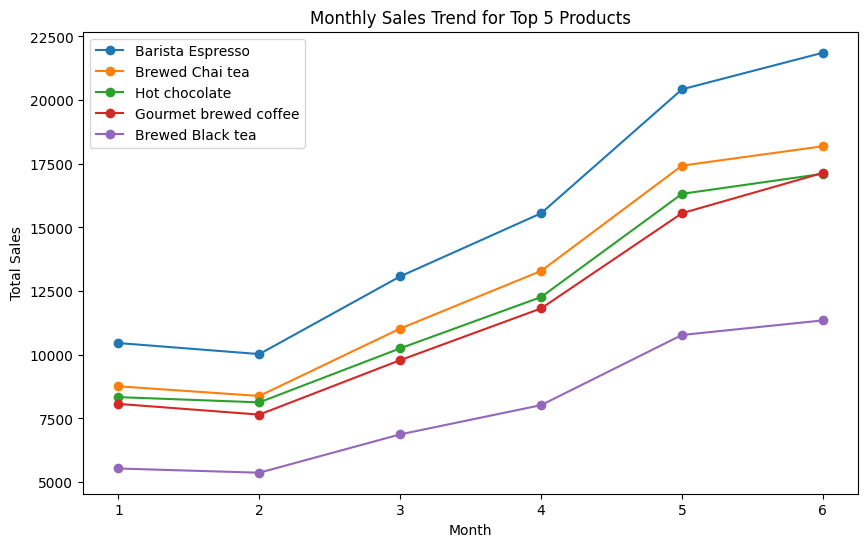

In [92]:
# Visualize the monthly sales trend for the top 5 products
top5_products = df.groupby('product')['sales'].sum().sort_values(ascending=False).head(5).index

filtered = monthly_product[monthly_product['product'].isin(top5_products)]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for product in top5_products:
    temp = filtered[filtered['product'] == product]
    plt.plot(temp['month'], temp['sales'], marker='o', label=product)

plt.legend()
plt.title("Monthly Sales Trend for Top 5 Products")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

Conclusion:
Based on the graph shown, there are several products that show an increase in sales in certain months, but there are no extreme spikes. Certain beverages show slight fluctuations, but these are not significant enough to be categorized as a strong seasonal pattern. Therefore, no dominant comfort drink pattern was found because all products were relatively stable throughout the period.

Kesimpulan:
Berdasarkan grafik yang ditampilkan ada beberapa produk yang menunjukkan peningkatan penjualan pada bulan tertentu, namun tidak terdapat lonjakan yang ekstrem. Minuman tertentu menunjukkan fluktuasi ringan, tetapi tidak cukup signifikan untuk dikategorikam sebagai pola musiman yang kuat. Sehingga Tidak ditemukan pola comfort drink yang sangat dominan karen seluruh produk relatuf stabil sepanjang periode.

QUESTION 3
Was there pseudo-product dominance in June? (Apakah terdapat pseudo-product dominance pada bulan Juni?)

In [93]:
# Analyze the sales trend for June
june_df = df[df['month'] == 6]

In [94]:
# Calculate total sales for each product in June and sort them in descending order
june_product = june_df.groupby('product')['sales'].sum().sort_values(ascending=False)
june_product

product
Barista Espresso         21860.00
Brewed Chai tea          18188.15
Gourmet brewed coffee    17142.00
Hot chocolate            17106.00
Brewed Black tea         11350.50
Brewed herbal tea        11211.00
Premium brewed coffee     9241.50
Organic brewed coffee     8775.00
Scone                     8551.89
Drip coffee               7770.50
Pastry                    6036.04
Brewed Green tea          5493.50
Biscotti                  4663.34
Premium Beans             4057.50
Organic Beans             2065.50
Housewares                1855.00
Clothing                  1558.00
Gourmet Beans             1500.00
Regular syrup             1430.40
Espresso Beans            1229.65
Chai tea                  1184.65
House blend Beans          810.00
Herbal tea                 626.50
Black tea                  626.50
Drinking Chocolate         612.16
Sugar free syrup           577.60
Organic Chocolate          380.00
Green tea                  333.00
Green beans                250.00
Name: 

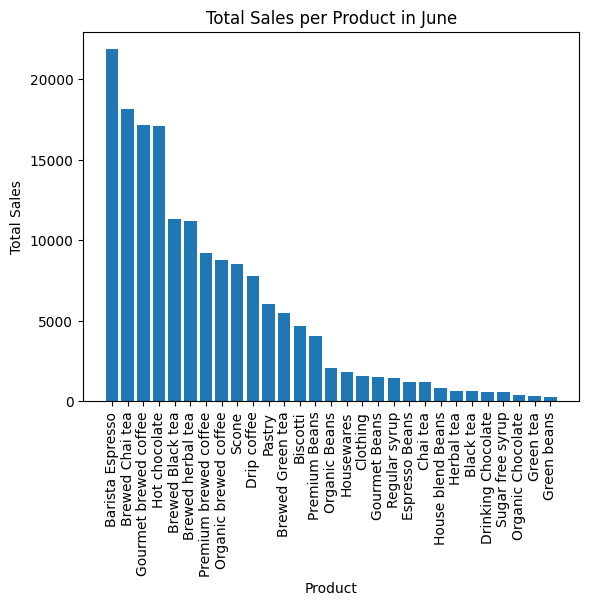

In [95]:
# Filtering the June data for the top products
june_df = df[df['month'] == 6]

# Calculate total sales for each product in June and sort them in descending order
june_product = june_df.groupby('product')['sales'].sum().sort_values(ascending=False)

plt.bar(june_product.index, june_product.values)
plt.xticks(rotation=90)
plt.title("Total Sales per Product in June")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.show()

Conclusion:
Based on the visualization of Total Sales per Product in June, it can be seen that Barista Espresso successfully ranked as the product with the highest total sales. Despite leading the market, Barista Espresso did not show extreme pseudo-product dominance, as sales contributions from other products such as Brewed Chai Tea, Gourmet Brewed Coffee, and Hot Chocolate were also quite significant. Analytically, the sales structure in June shows a very healthy and balanced product portfolio. No single product dominates the market excessively or overwhelmingly; rather, sales are distributed relatively evenly across several major product categories. This indicates that the store's dependence on a single type of product is very low, so that revenue stability is better maintained because it is supported by a variety of products that are equally popular with customers.

Kesimpulan:
Berdasarkan hasil visualisasi Total Sales per Product pada bulan Juni, terlihat bahwa Barista Espresso berhasil menempati posisi sebagai produk dengan total penjualan tertinggi. Meskipun memimpin pasar, Barista Espresso tidak menunjukkan dominasi produk (pseudo-product dominance) yang ekstrem, karena kontribusi penjualan dari produk lain seperti Brewed Chai Tea, Gourmet Brewed Coffee, dan Hot Chocolate juga tercatat cukup signifikan. Secara analitis, struktur penjualan di bulan Juni menunjukkan portofolio produk yang sangat sehat dan seimbang. Tidak ada satu produk pun yang menguasai pasar secara berlebihan atau overwhelming, melainkan penjualan terdistribusi secara relatif merata di antara beberapa kategori produk utama. Hal ini mengindikasikan bahwa ketergantungan toko terhadap satu jenis produk sangat rendah, sehingga stabilitas pendapatan lebih terjaga karena didukung oleh berbagai varian produk yang sama-sama diminati pelanggan.


QUESTION 4
Which products have a very large quantity but relatively small sales? (Produk apa yang memiliki quantity sangat besar tetapi sales relatif kecil?)

In [96]:
# Calculate total sales and quantities for each product
product_summary = df.groupby('product').agg({
    'quantity': 'sum',
    'sales': 'sum'
}).reset_index()

product_summary

,product,quantity,sales
0,Barista Espresso,24943,91406.20
1,Biscotti,5788,19793.53
2,Black tea,303,2711.85
3,Brewed Black tea,17462,47932.00
4,Brewed Chai tea,26250,77081.95
5,Brewed Green tea,8697,23852.50
6,Brewed herbal tea,17328,47539.50
7,Chai tea,443,4301.25
8,Clothing,221,6163.00
9,Drinking Chocolate,266,2728.04


In [97]:
# Calculate price per unit for each product
product_summary['price_per_unit'] = (
    product_summary['sales'] / product_summary['quantity']
)

product_summary

,product,quantity,sales,price_per_unit
0,Barista Espresso,24943,91406.20,3.664603
1,Biscotti,5788,19793.53,3.419753
2,Black tea,303,2711.85,8.950000
3,Brewed Black tea,17462,47932.00,2.744932
4,Brewed Chai tea,26250,77081.95,2.936455
5,Brewed Green tea,8697,23852.50,2.742612
6,Brewed herbal tea,17328,47539.50,2.743508
7,Chai tea,443,4301.25,9.709368
8,Clothing,221,6163.00,27.886878
9,Drinking Chocolate,266,2728.04,10.255789


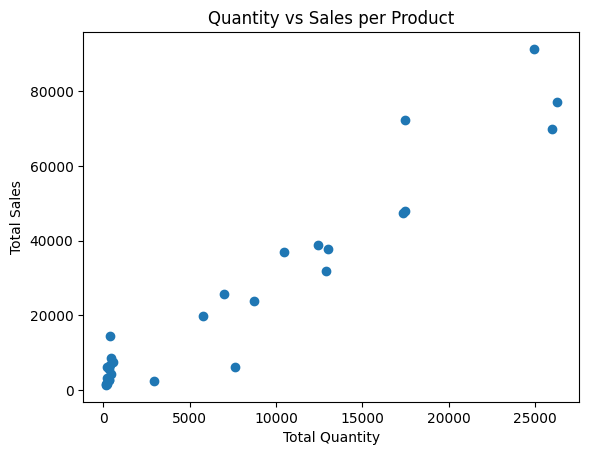

In [98]:
# Sort products by quantity sold in descending order
high_volume = product_summary.sort_values('quantity', ascending=False)

plt.scatter(product_summary['quantity'], product_summary['sales'])
plt.xlabel("Total Quantity")
plt.ylabel("Total Sales")
plt.title("Quantity vs Sales per Product")
plt.show()

Conclusion:
Based on the aggregation of total quantity and total sales per product, a clear differentiation in strategy was found in the current product portfolio. Products with high sales volume (total quantity) but relatively lower total revenue (sales) indicate the application of a volume-based strategy. Products in this category function as mass products that rely on high purchase frequency and fast stock turnover, despite having a tendency toward low unit prices and margins. Conversely, a group of products with smaller sales quantities but capable of contributing significantly to revenue was also found. This phenomenon is a strong indication of Premium Positioning, where products have a higher unit price with a thicker margin. Overall, the combination of volume-based products that keep cash flow active and premium products that boost profitability shows a fairly robust and varied business structure in targeting different market segments.

Kesimpulan:
Berdasarkan hasil agregasi total kuantitas dan total penjualan per produk, ditemukan diferensiasi strategi yang jelas dalam portofolio produk saat ini. Produk dengan volume penjualan (total quantity) yang tinggi namun menghasilkan total pendapatan (sales) yang relatif lebih rendah mengindikasikan penerapan Volume-based Strategy. Produk-produk dalam kategori ini berfungsi sebagai mass product yang mengandalkan frekuensi pembelian tinggi dan perputaran stok yang cepat, meskipun memiliki harga per unit dan margin yang cenderung kecil. Sebaliknya, ditemukan pula kelompok produk dengan kuantitas penjualan yang lebih kecil namun mampu memberikan kontribusi pendapatan yang signifikan. Fenomena ini merupakan indikasi kuat dari Premium Positioning, di mana produk memiliki harga per unit yang lebih mahal dengan margin yang lebih tebal. Secara keseluruhan, kombinasi antara produk berbasis volume yang menjaga arus kas tetap aktif dan produk premium yang mendongkrak profitabilitas menunjukkan struktur bisnis yang cukup tangguh dan variatif dalam menyasar segmen pasar yang berbeda.

QUESTION 5
Are overall sales stable or volatile? (Apakah penjualan secara keseluruhan stabil atau volatile?)

In [99]:
# Analyze the daily sales trend
daily_sales = df.groupby('date')['sales'].sum().reset_index()
daily_sales.head()

,date,sales
0,2023-01-01,2508.20
1,2023-01-02,2403.35
2,2023-01-03,2565.00
3,2023-01-04,2220.10
4,2023-01-05,2418.85


In [100]:
# Calculate mean, standard deviation, and coefficient of variation for daily sales
mean_sales = daily_sales['sales'].mean()
std_sales = daily_sales['sales'].std()

cv = std_sales / mean_sales

mean_sales, std_sales, cv

(3860.841602209945, 1187.8220295866327, 0.307658835033979)

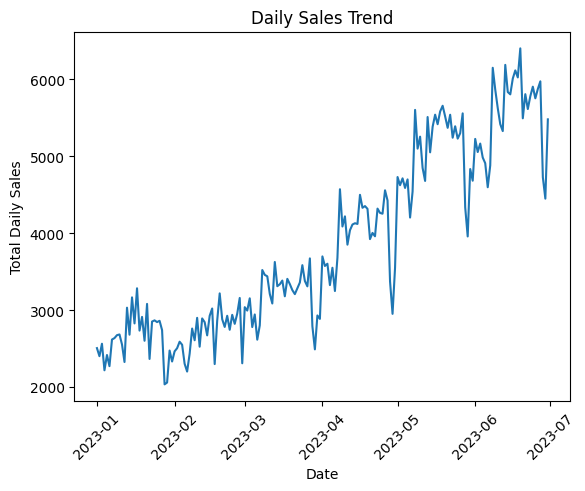

In [101]:
# Visualize the daily sales trend
plt.plot(daily_sales['date'], daily_sales['sales'])
plt.xlabel("Date")
plt.ylabel("Total Daily Sales")
plt.title("Daily Sales Trend")
plt.xticks(rotation=45)
plt.show()

Conclusion:
Based on the data visualization results, business performance shows a positive cumulative growth trend from January to June. Although the main trajectory is upward, the graph also shows several sharp declines and significant daily fluctuations. This indicates that even though market expansion is occurring, daily operations still face dynamic variations and are not entirely stable. Technically, this level of instability is validated by a coefficient of variation value of 0.307, which categorizes daily sales as volatile. This figure provides a strategic signal that the fluctuations that occur are quite large compared to the average value. Therefore, even though the business is on a growth path, management needs to be aware of the factors causing daily volatility in order to maintain consistent performance and mitigate the risk of sudden declines in the future.

Kesimpulan:
Berdasarkan hasil visualisasi data, performa bisnis menunjukkan tren pertumbuhan (growth trend) yang positif secara akumulatif dari bulan Januari hingga Juni. Meskipun lintasan utama bergerak naik, grafik tersebut juga memperlihatkan adanya beberapa penurunan tajam serta fluktuasi harian yang cukup signifikan. Hal ini mengindikasikan bahwa meskipun ekspansi pasar sedang terjadi, operasional harian masih menghadapi variasi yang dinamis dan tidak sepenuhnya stabil. Secara teknis, tingkat ketidakstabilan ini divalidasi oleh nilai koefisien variasi sebesar 0.307, yang mengategorikan penjualan harian ke dalam kelompok volatil. Angka ini memberikan sinyal strategis bahwa fluktuasi yang terjadi cukup besar dibandingkan dengan nilai rata-ratanya. Oleh karena itu, meskipun bisnis berada dalam jalur pertumbuhan, manajemen perlu mewaspadai faktor-faktor penyebab volatilitas harian tersebut guna menjaga konsistensi performa dan memitigasi risiko penurunan mendadak di masa mendatang.

QUESTION 6
Is there cannibalization between products? (Apakah ada Cannibalization antar produk?)

In [102]:
#make the pivot table to analyze the sales trend for each product over time
pivot_product = df.pivot_table(
    index='date',
    columns='product',
    values='quantity',
    aggfunc='sum'
)

pivot_product.head()

product,Barista Espresso,Biscotti,Black tea,Brewed Black tea,Brewed Chai tea,Brewed Green tea,Brewed herbal tea,Chai tea,Clothing,Drinking Chocolate,...,Housewares,Organic Beans,Organic Chocolate,Organic brewed coffee,Pastry,Premium Beans,Premium brewed coffee,Regular syrup,Scone,Sugar free syrup
date,,,,,,,,,,,,,,,,,,,,,
2023-01-01,109.0,18.0,NaN,60.0,114.0,35.0,77.0,NaN,NaN,NaN,...,NaN,NaN,NaN,57.0,22.0,NaN,63.0,NaN,28.0,NaN
2023-01-02,84.0,21.0,NaN,71.0,101.0,45.0,57.0,NaN,NaN,NaN,...,NaN,NaN,NaN,71.0,23.0,NaN,44.0,NaN,43.0,NaN
2023-01-03,106.0,22.0,NaN,88.0,105.0,38.0,65.0,NaN,NaN,NaN,...,NaN,NaN,NaN,73.0,21.0,NaN,46.0,NaN,38.0,NaN
2023-01-04,75.0,19.0,NaN,69.0,88.0,37.0,72.0,NaN,NaN,NaN,...,NaN,NaN,NaN,54.0,21.0,NaN,63.0,NaN,21.0,NaN
2023-01-05,113.0,9.0,NaN,93.0,79.0,38.0,77.0,NaN,NaN,NaN,...,NaN,NaN,NaN,45.0,21.0,NaN,59.0,NaN,43.0,NaN


In [103]:
# Calculate the correlation matrix for the pivot table
corr_matrix = pivot_product.corr()

corr_matrix.head()

product,Barista Espresso,Biscotti,Black tea,Brewed Black tea,Brewed Chai tea,Brewed Green tea,Brewed herbal tea,Chai tea,Clothing,Drinking Chocolate,...,Housewares,Organic Beans,Organic Chocolate,Organic brewed coffee,Pastry,Premium Beans,Premium brewed coffee,Regular syrup,Scone,Sugar free syrup
product,,,,,,,,,,,,,,,,,,,,,
Barista Espresso,1.000000,0.682108,0.227820,0.813353,0.861108,0.779233,0.880784,0.407119,0.214957,0.397621,...,0.187274,0.226210,0.275626,0.802759,0.642206,0.203999,0.821924,0.458111,0.831959,0.435310
Biscotti,0.682108,1.000000,0.211960,0.645822,0.656677,0.478080,0.640529,0.641727,0.365454,0.383173,...,0.418717,0.585988,0.348854,0.573669,0.739658,0.337465,0.669882,0.703181,0.706845,0.708380
Black tea,0.227820,0.211960,1.000000,0.143526,0.129267,0.173665,0.161506,0.207279,0.217128,0.458958,...,0.464021,0.060787,0.408732,0.176384,0.200398,0.050382,0.181797,0.243940,0.189272,0.322644
Brewed Black tea,0.813353,0.645822,0.143526,1.000000,0.809027,0.677158,0.788324,0.467135,0.095447,0.309024,...,0.091087,0.287646,0.201436,0.761616,0.691580,0.233900,0.790101,0.518141,0.671369,0.516535
Brewed Chai tea,0.861108,0.656677,0.129267,0.809027,1.000000,0.824796,0.867320,0.365285,0.073390,0.272326,...,0.098617,0.249629,0.259035,0.810044,0.665548,0.159143,0.823368,0.414158,0.751729,0.418958


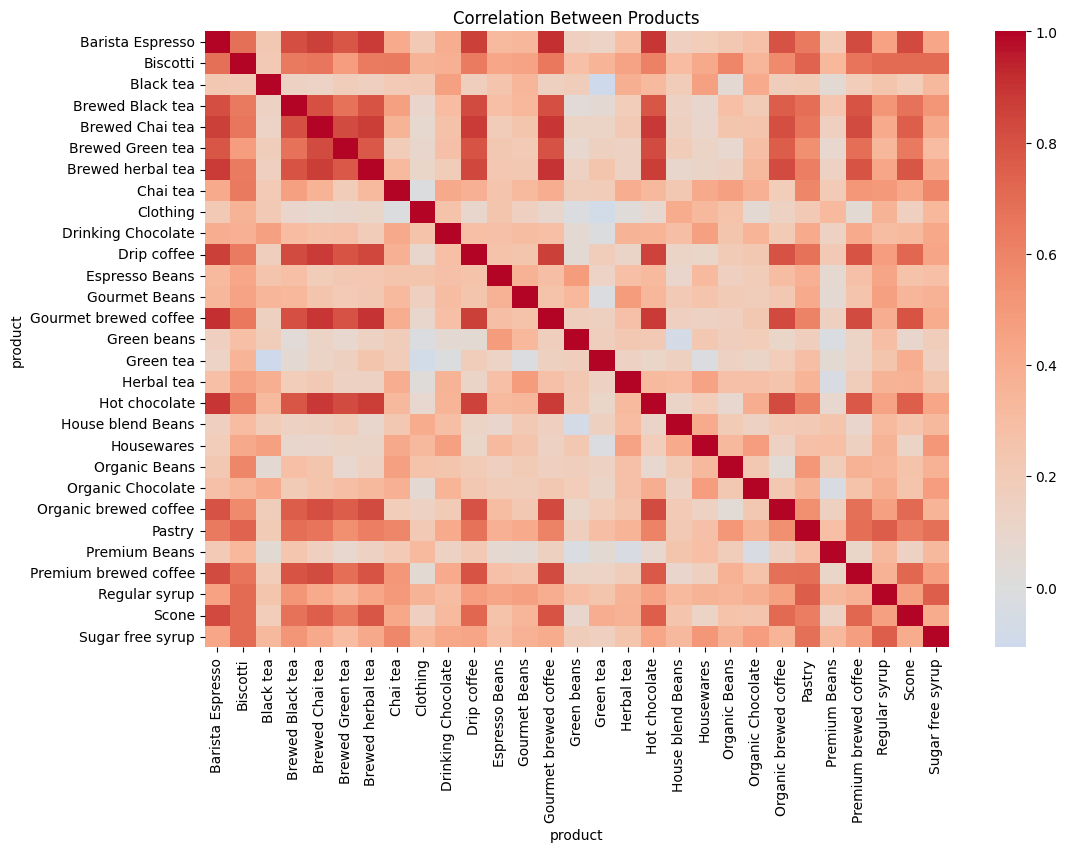

In [104]:
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Correlation Between Products")
plt.show()

Conclusion:
Based on the correlation analysis between products, no significant negative correlation values (< -0.3) were found. This indicates that there is no strong indication of cannibalization between products. Most products have a positive correlation, which means that an increase in sales of one product tends to be followed by an increase in sales of other products. This indicates a complementary demand pattern or one that is influenced by external factors such as traffic and seasonality.

Kesimpulan:
Berdasarkan analisis korelasi antar produk, tidak ditemukan nilai korelasi negatif yang signifikan (< -0.3). Hal ini menunjukkan tidak adanya indikasi cannibalization yang kuat antar produk. Sebagian besar produk memiliki korelasi positif, yang berarti kenaikan penjualan satu produk cenderung diikuti kenaikan produk lain. Ini mengindikasikan pola permintaan yang bersifat komplementer atau dipengaruhi faktor eksternal seperti traffic dan seasonality

QUESTION 7
How stable is the performance of each store? (Seberapa stabil performa masing-masing store?)

In [105]:
# Analyze the sales trend for each store over time
daily_store = df.groupby(['date','store'])['sales'].sum().reset_index()

daily_store.head()

,date,store,sales
0,2023-01-01,Astoria,868.40
1,2023-01-01,Hell's Kitchen,851.45
2,2023-01-01,Lower Manhattan,788.35
3,2023-01-02,Astoria,925.50
4,2023-01-02,Hell's Kitchen,828.80


In [106]:
# Calculate mean, standard deviation, and coefficient of variation for daily sales per store
store_volatility = daily_store.groupby('store')['sales'].agg(['mean','std'])

store_volatility['cv'] = store_volatility['std'] / store_volatility['mean']

store_volatility

,mean,std,cv
store,,,
Astoria,1283.115525,426.444617,0.332351
Hell's Kitchen,1306.691547,441.737839,0.338058
Lower Manhattan,1271.034530,425.637615,0.334875


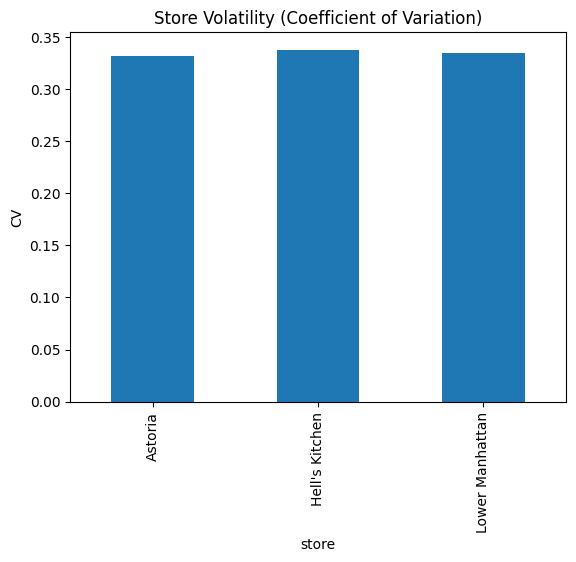

In [107]:
# Visualize the store volatility using a bar chart
store_volatility['cv'].plot(kind='bar')
plt.title("Store Volatility (Coefficient of Variation)")
plt.ylabel("CV")
plt.show()

Conclusion:
Based on the Coefficient of Variation (CV) calculation, the three stores show relatively similar levels of volatility (around 0.33–0.34). This indicates that there is no significant difference in the stability of sales performance between stores. The fluctuations that occur are likely to be influenced more by external factors such as seasonal patterns or customer traffic than by the operational factors of each store.

Kesimpulan:
Berdasarkan perhitungan Coefficient of Variation (CV), ketiga store menunjukkan tingkat volatilitas yang relatif serupa (sekitar 0.33–0.34). Hal ini mengindikasikan bahwa stabilitas performa penjualan antar store tidak memiliki perbedaan signifikan. Fluktuasi yang terjadi kemungkinan lebih dipengaruhi oleh faktor eksternal seperti pola musiman atau traffic pelanggan dibandingkan faktor operasional masing-masing store.